# Chapter 17 Representation Learning and Generative Learning Using Autoencoders and GANs

## 17.3 Stacked Autoencoders

#### MNIST

##### Data

In [1]:
from sklearn.datasets import fetch_openml

x, y = fetch_openml(
    "mnist_784", version=1, return_X_y=True, as_frame=False, parser="pandas"
)

In [2]:
import matplotlib.pyplot as plt
from typing import Optional, Sequence

%matplotlib inline


def plot_images(
    images_norm: Sequence[Sequence[Sequence[float]]],
    labels: Sequence[int],
    label_text: str = "Label",
    n_cols: int = 10,
    sup_title: Optional[str] = None,
) -> None:
    n_images = len(images_norm)
    n_rows = round(np.ceil(n_images / n_cols))
    fig, axs = plt.subplots(
        nrows=n_rows,
        ncols=n_cols,
        squeeze=False,
        figsize=(20, n_rows * 2 + 1),
        constrained_layout=True,
    )
    for ax, img, label in zip(axs.ravel(), images_norm, labels):
        ax.imshow(img, cmap="gray")
        ax.axis("off")
        ax.set_title(f"{label_text}: {label}", fontsize="large", fontweight="bold")
    if sup_title is not None:
        fig.suptitle(sup_title, fontsize="x-large", fontweight="bold")

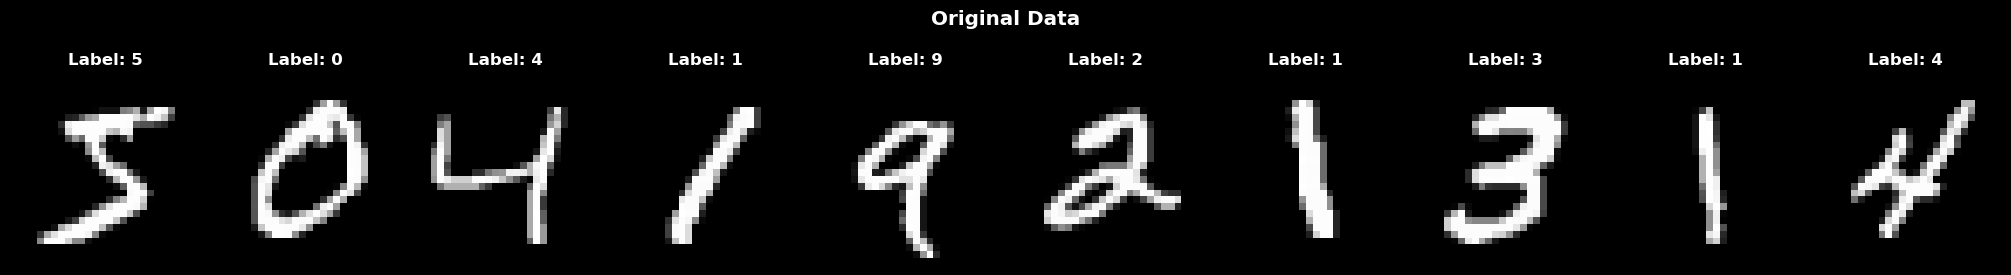

In [3]:
import numpy as np

n_instances = 10
plot_images(
    images_norm=x[:n_instances].reshape(-1, 28, 28),
    labels=y[:n_instances],
    sup_title="Original Data",
)

In [4]:
import pandas as pd

pd.DataFrame(x).describe()

,0,1,2,3,4,5,6,7,8,9,...,774,775,776,777,778,779,780,781,782,783
count,70000.0,70000.0,70000.0,70000.0,70000.0,70000.0,70000.0,70000.0,70000.0,70000.0,...,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.0,70000.0,70000.0,70000.0
mean,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.197414,0.099543,0.046629,0.016614,0.012957,0.001714,0.0,0.0,0.0,0.0
std,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,5.991206,4.256304,2.783732,1.561822,1.553796,0.320889,0.0,0.0,0.0,0.0
min,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0
25%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0
50%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0
75%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0
max,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,254.000000,254.000000,253.000000,253.000000,254.000000,62.000000,0.0,0.0,0.0,0.0


In [5]:
y[:5]

array(['5', '0', '4', '1', '9'], dtype=object)

In [6]:
x_norm = x / 255.0

In [7]:
from sklearn.model_selection import train_test_split

x_train_valid, x_test, y_train_valid, y_test = train_test_split(
    x_norm, y, test_size=0.01, random_state=42
)
x_train, x_valid, y_train, y_valid = train_test_split(
    x_train_valid, y_train_valid, test_size=0.2, random_state=42
)

print("x_train:", x_train.shape)
print("x_valid:", x_valid.shape)
print("x_test:", x_test.shape)

x_train: (55440, 784)
x_valid: (13860, 784)
x_test: (700, 784)


##### Model

In [8]:
import tensorflow as tf

encoder = tf.keras.models.Sequential(
    [
        tf.keras.layers.Dense(
            100,
            activation="selu",
            kernel_initializer="lecun_normal",
            input_shape=(784,),
        ),
        tf.keras.layers.Dense(30, activation="selu", kernel_initializer="lecun_normal"),
    ]
)
decoder = tf.keras.models.Sequential(
    [
        tf.keras.layers.Dense(
            100, activation="selu", kernel_initializer="lecun_normal", input_shape=(30,)
        ),
        tf.keras.layers.Dense(784, activation="sigmoid"),
    ]
)
autoencoder = tf.keras.models.Sequential(
    [
        encoder,
        decoder,
    ]
)
autoencoder.compile(optimizer="adam", loss="binary_crossentropy")
autoencoder.summary()

2023-07-24 10:09:16.872318: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 sequential (Sequential)     (None, 30)                81530     
                                                                 
 sequential_1 (Sequential)   (None, 784)               82284     
                                                                 
Total params: 163,814
Trainable params: 163,814
Non-trainable params: 0
_________________________________________________________________


2023-07-24 10:09:18.459306: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:980] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2023-07-24 10:09:18.489138: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:980] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2023-07-24 10:09:18.489395: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:980] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2023-07-24 10:09:18.489834: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropri

In [9]:
cb_early_stopping = tf.keras.callbacks.EarlyStopping(
    patience=5, restore_best_weights=True
)
history = autoencoder.fit(
    x_train,
    x_train,
    epochs=20,
    validation_data=[x_valid, x_valid],
    callbacks=[cb_early_stopping],
)

Epoch 1/20
1733/1733 [==============================] - 5s 3ms/step - loss: 0.1373 - val_loss: 0.1120
Epoch 2/20
1733/1733 [==============================] - 5s 3ms/step - loss: 0.1082 - val_loss: 0.1044
Epoch 3/20
1733/1733 [==============================] - 5s 3ms/step - loss: 0.1021 - val_loss: 0.1002
Epoch 4/20
1733/1733 [==============================] - 6s 4ms/step - loss: 0.0980 - val_loss: 0.0959
Epoch 5/20
1733/1733 [==============================] - 5s 3ms/step - loss: 0.0943 - val_loss: 0.0930
Epoch 6/20
1733/1733 [==============================] - 5s 3ms/step - loss: 0.0921 - val_loss: 0.0916
Epoch 7/20
1733/1733 [==============================] - 5s 3ms/step - loss: 0.0908 - val_loss: 0.0902
Epoch 8/20
1733/1733 [==============================] - 5s 3ms/step - loss: 0.0897 - val_loss: 0.0892
Epoch 9/20
1733/1733 [==============================] - 5s 3ms/step - loss: 0.0882 - val_loss: 0.0877
Epoch 10/20
1733/1733 [==============================] - 6s 3ms/step - loss: 0.087

##### Evaluation

22/22 [==============================] - 0s 2ms/step


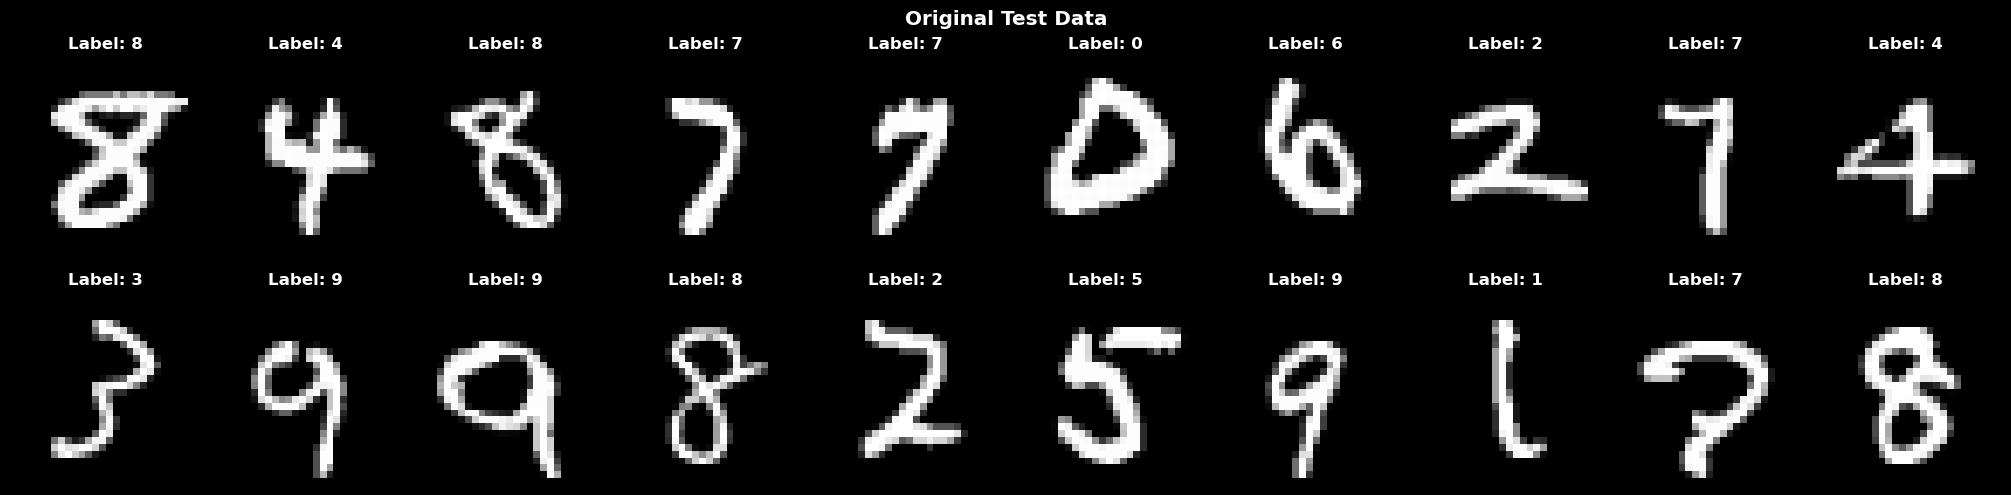

In [10]:
x_test_rec = autoencoder.predict(x_test)

n_instances_test = 20
plot_images(
    images_norm=x_test[:n_instances_test].reshape(-1, 28, 28),
    labels=y_test[:n_instances_test],
    sup_title="Original Test Data",
)

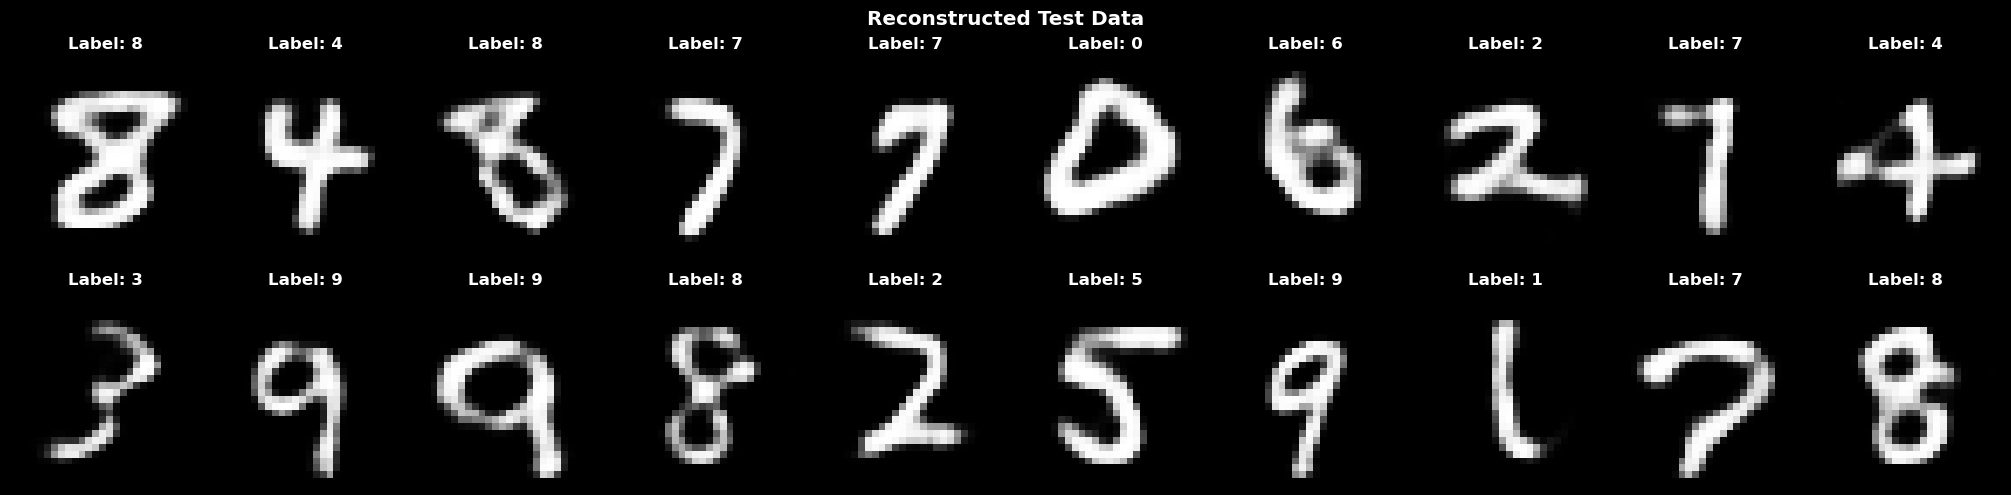

In [11]:
plot_images(
    images_norm=x_test_rec[:n_instances_test].reshape(-1, 28, 28),
    labels=y_test[:n_instances_test],
    sup_title="Reconstructed Test Data",
)

#### Fashion MNIST

##### Data

In [12]:
import tensorflow as tf
from sklearn.model_selection import train_test_split

(
    (x_train_valid, y_train_valid),
    (
        x_test,
        y_test,
    ),
) = tf.keras.datasets.fashion_mnist.load_data()
x_train, x_valid, y_train, y_valid = train_test_split(
    x_train_valid, y_train_valid, test_size=0.2, random_state=42
)

print("x_train:", x_train.shape)
print("x_valid:", x_valid.shape)
print("x_test:", x_test.shape)

x_train: (48000, 28, 28)
x_valid: (12000, 28, 28)
x_test: (10000, 28, 28)


In [13]:
import pandas as pd

pd.DataFrame(x_train.reshape(-1, 28 * 28)).describe()

,0,1,2,3,4,5,6,7,8,9,...,774,775,776,777,778,779,780,781,782,783
count,48000.000000,48000.000000,48000.000000,48000.000000,48000.000000,48000.000000,48000.000000,48000.000000,48000.000000,48000.000000,...,48000.000000,48000.000000,48000.000000,48000.000000,48000.000000,48000.000000,48000.000000,48000.000000,48000.000000,48000.000000
mean,0.000812,0.004833,0.028854,0.111083,0.249625,0.425271,0.833208,2.229437,5.691958,14.399250,...,34.457937,23.035521,16.402208,17.729187,22.964333,17.901229,8.457875,2.691875,0.810979,0.069896
std,0.098211,0.173980,0.599051,2.731625,4.392039,6.061629,8.484823,14.198763,23.868188,38.158641,...,57.520838,48.653593,41.793626,43.785093,51.937184,45.077433,29.337078,17.258526,9.061606,2.104751
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,57.000000,8.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,16.000000,16.000000,56.000000,164.000000,224.000000,230.000000,221.000000,221.000000,254.000000,255.000000,...,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,170.000000


In [14]:
y_train[:5]

array([7, 3, 5, 8, 6], dtype=uint8)

In [15]:
import numpy as np

classes = np.array(
    [
        "T-shirt/top",
        "Trouser",
        "Pullover",
        "Dress",
        "Coat",
        "Sandal",
        "Shirt",
        "Sneaker",
        "Bag",
        "Ankle boot",
    ]
)

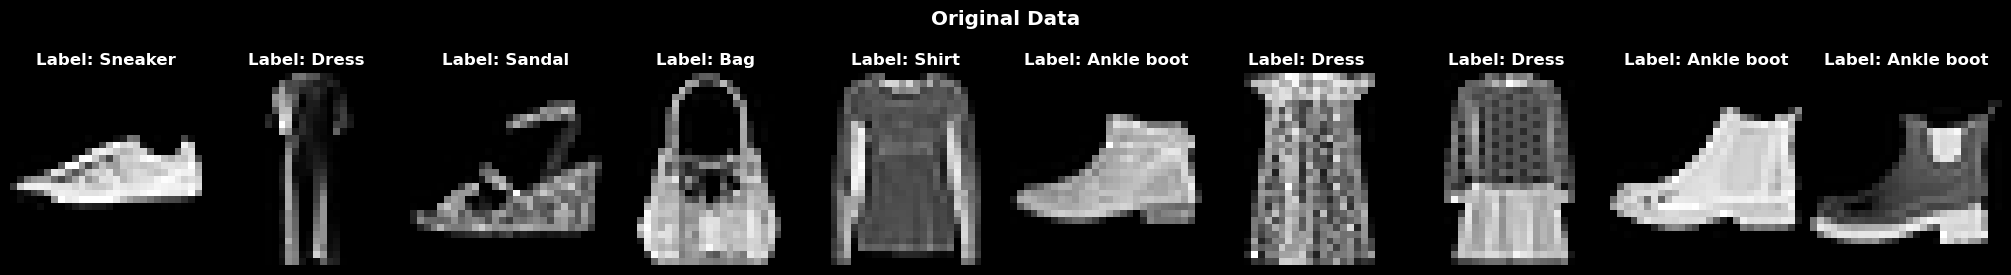

In [16]:
n_instances = 10
plot_images(
    images_norm=x_train[:n_instances],
    labels=classes[y_train[:n_instances]],
    sup_title="Original Data",
)

In [17]:
x_train_norm = x_train / 255.0
x_valid_norm = x_valid / 255.0
x_test_norm = x_test / 255.0

##### Model

In [18]:
import tensorflow as tf

encoder = tf.keras.models.Sequential(
    [
        tf.keras.layers.Flatten(input_shape=(28, 28)),
        tf.keras.layers.Dense(
            100, activation="selu", kernel_initializer="lecun_normal"
        ),
        tf.keras.layers.Dense(30, activation="selu", kernel_initializer="lecun_normal"),
    ]
)
decoder = tf.keras.models.Sequential(
    [
        tf.keras.layers.Dense(
            100, activation="selu", kernel_initializer="lecun_normal", input_shape=(30,)
        ),
        tf.keras.layers.Dense(784, activation="sigmoid"),
        tf.keras.layers.Reshape((28, 28)),
    ]
)
autoencoder = tf.keras.models.Sequential([encoder, decoder])
autoencoder.compile(optimizer="adam", loss="binary_crossentropy")
autoencoder.summary()

Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 sequential_3 (Sequential)   (None, 30)                81530     
                                                                 
 sequential_4 (Sequential)   (None, 28, 28)            82284     
                                                                 
Total params: 163,814
Trainable params: 163,814
Non-trainable params: 0
_________________________________________________________________


In [19]:
cb_early_stopping = tf.keras.callbacks.EarlyStopping(
    patience=5, restore_best_weights=True
)
history = autoencoder.fit(
    x_train_norm,
    x_train_norm,
    epochs=20,
    validation_data=[x_valid_norm, x_valid_norm],
    callbacks=[cb_early_stopping],
)

Epoch 1/20
1500/1500 [==============================] - 4s 2ms/step - loss: 0.3088 - val_loss: 0.2903
Epoch 2/20
1500/1500 [==============================] - 3s 2ms/step - loss: 0.2863 - val_loss: 0.2838
Epoch 3/20
1500/1500 [==============================] - 3s 2ms/step - loss: 0.2824 - val_loss: 0.2813
Epoch 4/20
1500/1500 [==============================] - 4s 2ms/step - loss: 0.2805 - val_loss: 0.2801
Epoch 5/20
1500/1500 [==============================] - 4s 2ms/step - loss: 0.2792 - val_loss: 0.2794
Epoch 6/20
1500/1500 [==============================] - 3s 2ms/step - loss: 0.2783 - val_loss: 0.2780
Epoch 7/20
1500/1500 [==============================] - 4s 2ms/step - loss: 0.2775 - val_loss: 0.2776
Epoch 8/20
1500/1500 [==============================] - 3s 2ms/step - loss: 0.2769 - val_loss: 0.2769
Epoch 9/20
1500/1500 [==============================] - 4s 3ms/step - loss: 0.2763 - val_loss: 0.2765
Epoch 10/20
1500/1500 [==============================] - 3s 2ms/step - loss: 0.275

##### Evaluation

313/313 [==============================] - 2s 4ms/step


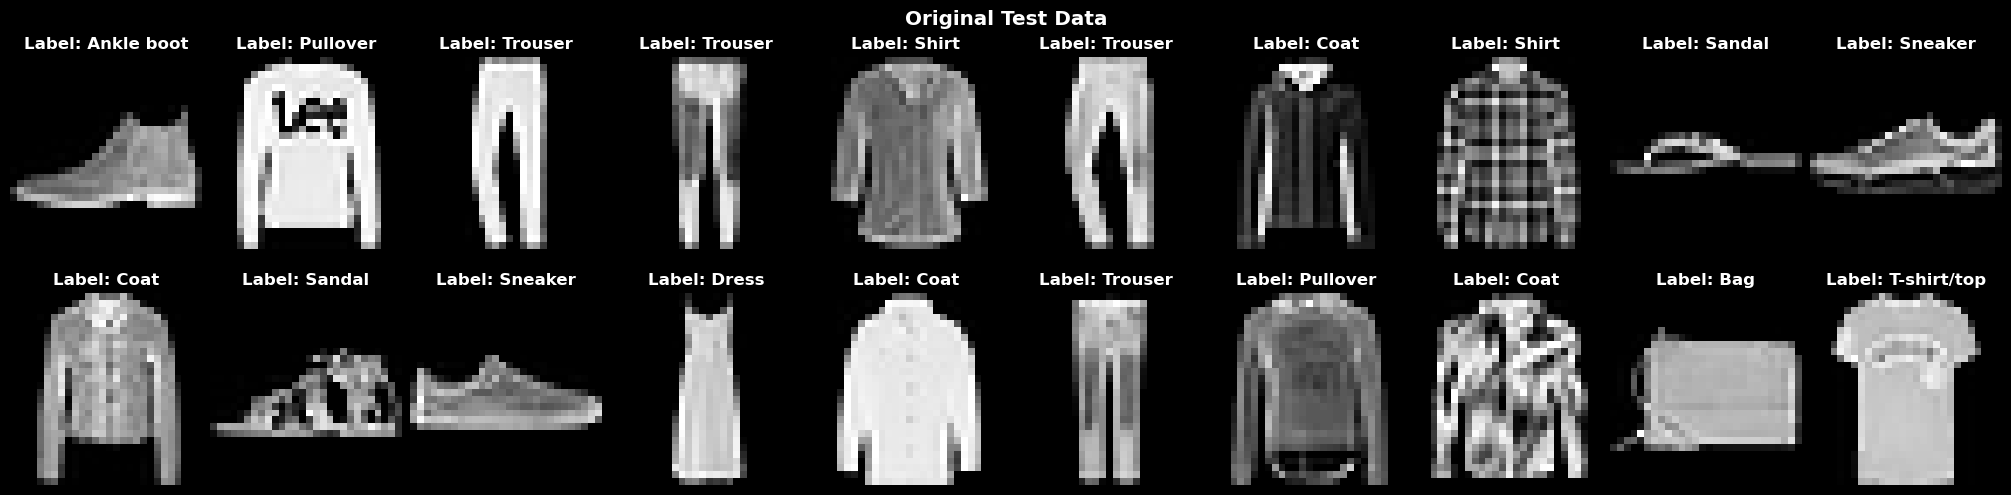

In [20]:
x_test_rec = autoencoder.predict(x_test_norm)

n_instances_test = 20
plot_images(
    images_norm=x_test[:n_instances_test],
    labels=classes[y_test[:n_instances_test]],
    sup_title="Original Test Data",
)

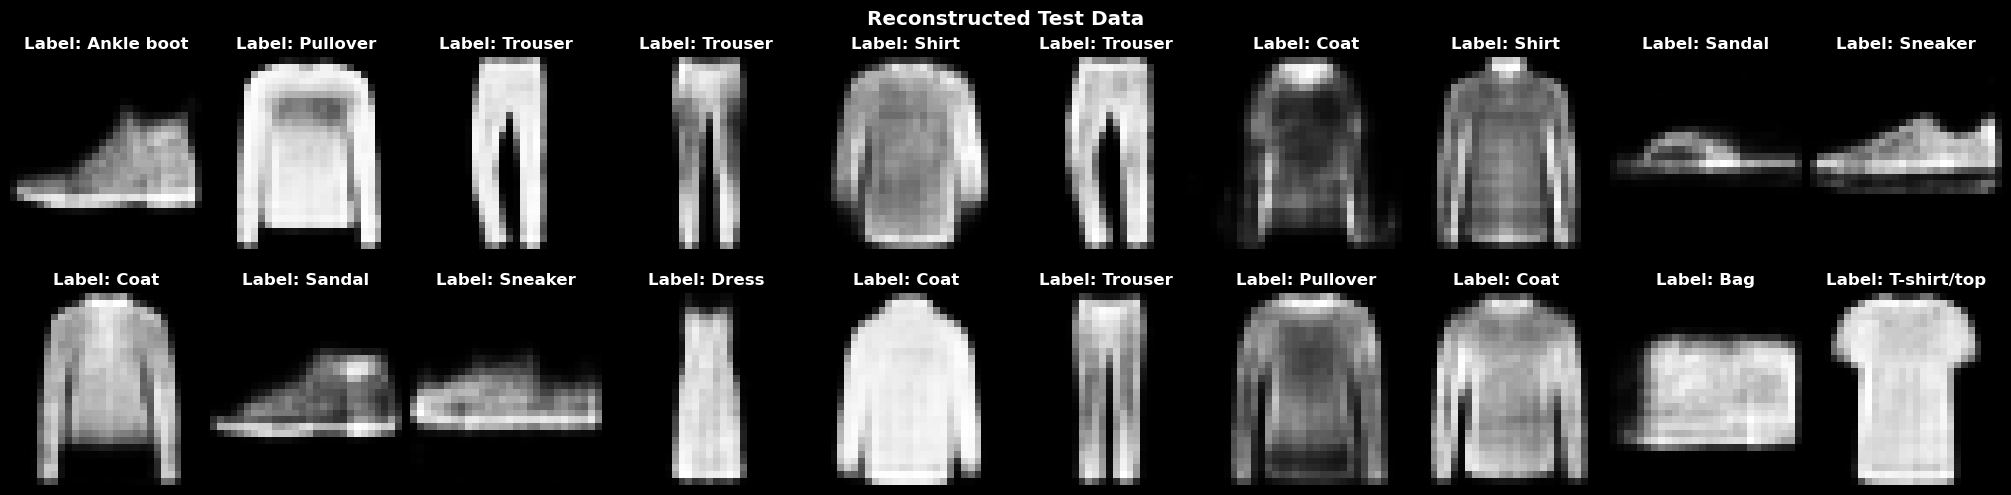

In [21]:
plot_images(
    images_norm=x_test_rec[:n_instances_test] * 255,
    labels=classes[y_test[:n_instances_test]],
    sup_title="Reconstructed Test Data",
)

##### Visualization

In [22]:
from sklearn.manifold import TSNE
from umap import UMAP

x_test_embedding = encoder.predict(x_test_norm)

# tsne = TSNE()
umap = UMAP()
x_test_2d = umap.fit_transform(x_test_embedding)

/home/yuncong/mambaforge/envs/tf210/lib/python3.10/site-packages/umap/distances.py:1063: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  @numba.jit()
/home/yuncong/mambaforge/envs/tf210/lib/python3.10/site-packages/umap/distances.py:1071: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  @numba.jit()
/home/yuncong/mambaforge/envs/tf210/lib/python3.10/site-packages/uma

 51/313 [===>..........................] - ETA: 0s 

/home/yuncong/mambaforge/envs/tf210/lib/python3.10/site-packages/umap/umap_.py:660: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  @numba.jit()


313/313 [==============================] - 0s 1ms/step


(-5.725137305259705, 17.316772532463073, -4.10433748960495, 14.963990247249603)

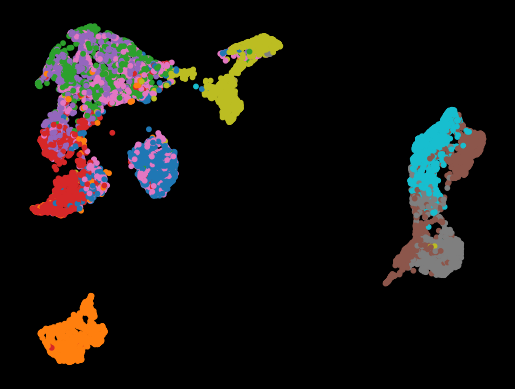

In [23]:
fig, ax = plt.subplots()
ax.scatter(x_test_2d[:, 0], x_test_2d[:, 1], c=y_test, s=10, cmap="tab10")
ax.axis("off")

#### Tying Weights

In [24]:
# Dense transpose layer
class DenseTranspose(tf.keras.layers.Layer):
    def __init__(self, dense: tf.keras.layers.Layer, activation: str, **kwargs) -> None:
        self.dense = dense
        self.activation = tf.keras.activations.get(activation)
        super(DenseTranspose, self).__init__(**kwargs)

    def build(self, batch_input_shape: tf.Tensor) -> None:
        self.biases = self.add_weight(
            name="bias", initializer="zeros", shape=(self.dense.input_shape[-1])
        )
        super().build(batch_input_shape)

    def call(self, inputs) -> tf.Tensor:
        z = tf.matmul(inputs, self.dense.weights[0], transpose_b=True)
        return self.activation(z + self.biases)

In [25]:
# Model
dense_1 = tf.keras.layers.Dense(
    100, activation="selu", kernel_initializer="lecun_normal"
)
dense_2 = tf.keras.layers.Dense(
    30, activation="selu", kernel_initializer="lecun_normal"
)

encoder_tied = tf.keras.models.Sequential(
    [tf.keras.layers.Flatten(input_shape=(28, 28)), dense_1, dense_2]
)
decoder_tied = tf.keras.models.Sequential(
    [
        DenseTranspose(dense_2, activation="selu"),
        DenseTranspose(dense_1, activation="sigmoid"),
        tf.keras.layers.Reshape((28, 28)),
    ]
)

autoencoder_tied = tf.keras.models.Sequential([encoder_tied, decoder_tied])

autoencoder_tied.compile(optimizer="adam", loss="binary_crossentropy")
autoencoder_tied.summary()

Model: "sequential_8"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 sequential_6 (Sequential)   (None, 30)                81530     
                                                                 
 sequential_7 (Sequential)   (None, 28, 28)            82414     
                                                                 
Total params: 82,414
Trainable params: 82,414
Non-trainable params: 0
_________________________________________________________________


In [26]:
cb_early_stopping = tf.keras.callbacks.EarlyStopping(
    patience=5, restore_best_weights=True
)
history = autoencoder_tied.fit(
    x_train_norm,
    x_train_norm,
    epochs=20,
    validation_data=[x_valid_norm, x_valid_norm],
    callbacks=[cb_early_stopping],
)

Epoch 1/20
1500/1500 [==============================] - 4s 3ms/step - loss: 0.3141 - val_loss: 0.2908
Epoch 2/20
1500/1500 [==============================] - 3s 2ms/step - loss: 0.2870 - val_loss: 0.2843
Epoch 3/20
1500/1500 [==============================] - 4s 2ms/step - loss: 0.2825 - val_loss: 0.2812
Epoch 4/20
1500/1500 [==============================] - 4s 2ms/step - loss: 0.2803 - val_loss: 0.2796
Epoch 5/20
1500/1500 [==============================] - 4s 2ms/step - loss: 0.2791 - val_loss: 0.2790
Epoch 6/20
1500/1500 [==============================] - 4s 2ms/step - loss: 0.2782 - val_loss: 0.2778
Epoch 7/20
1500/1500 [==============================] - 4s 2ms/step - loss: 0.2775 - val_loss: 0.2774
Epoch 8/20
1500/1500 [==============================] - 4s 2ms/step - loss: 0.2770 - val_loss: 0.2769
Epoch 9/20
1500/1500 [==============================] - 3s 2ms/step - loss: 0.2766 - val_loss: 0.2769
Epoch 10/20
1500/1500 [==============================] - 4s 2ms/step - loss: 0.276

##### Evaluation

313/313 [==============================] - 1s 1ms/step


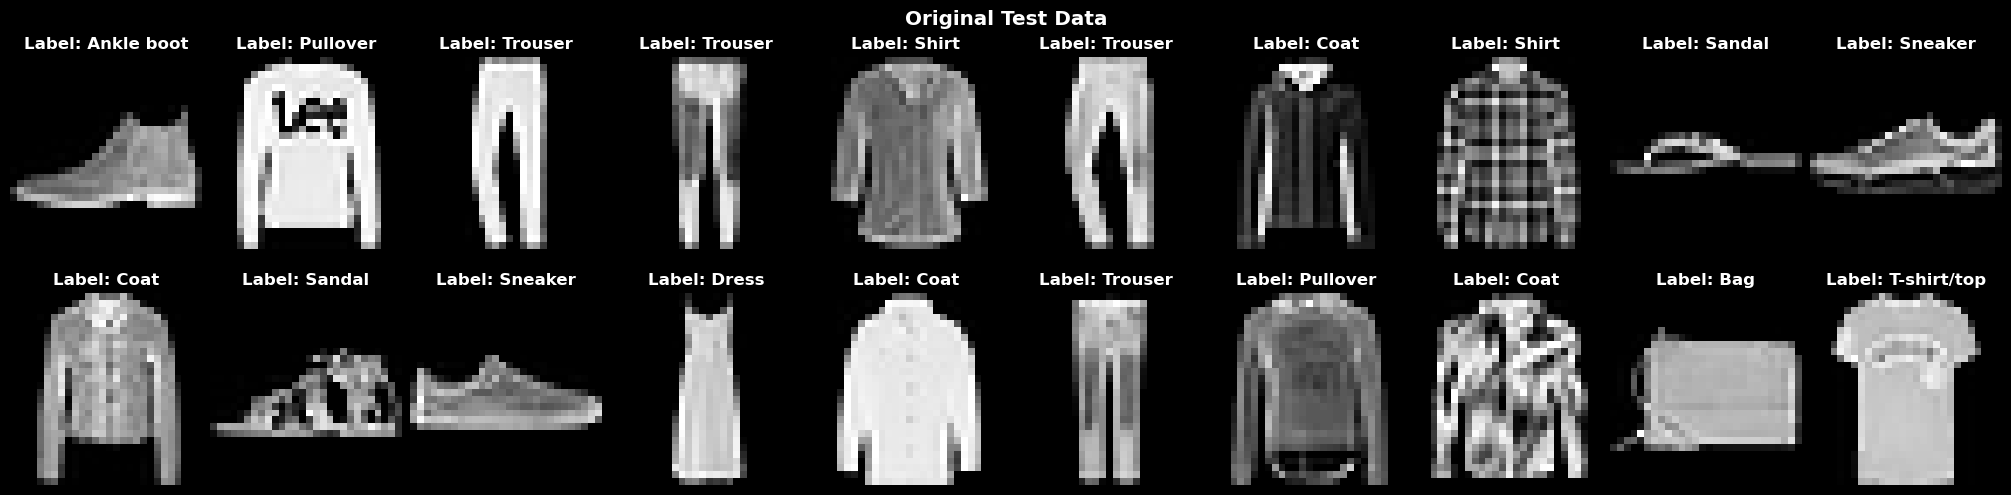

In [27]:
x_test_rec = autoencoder_tied.predict(x_test_norm)

n_instances_test = 20
plot_images(
    images_norm=x_test[:n_instances_test],
    labels=classes[y_test[:n_instances_test]],
    sup_title="Original Test Data",
)

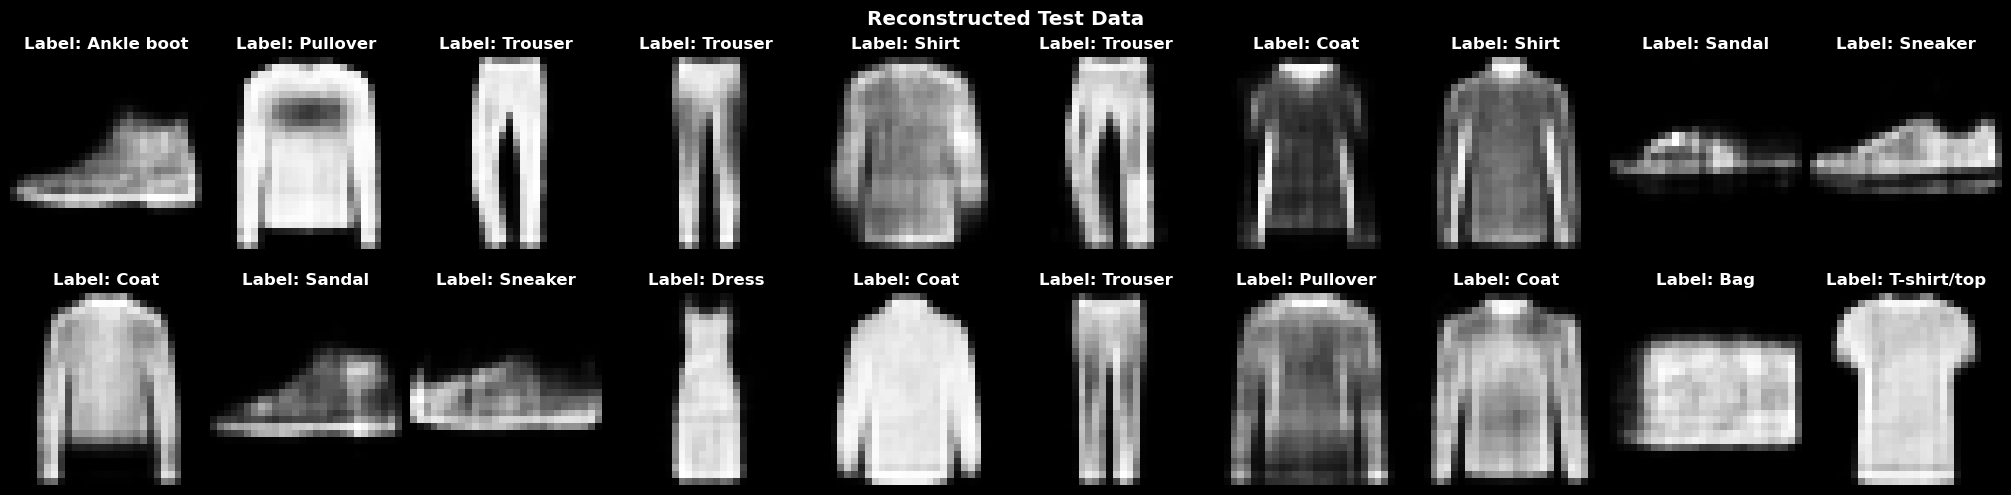

In [28]:
plot_images(
    images_norm=x_test_rec[:n_instances_test] * 255,
    labels=classes[y_test[:n_instances_test]],
    sup_title="Reconstructed Test Data",
)

##### Visualization

In [29]:
from sklearn.manifold import TSNE
from umap import UMAP

x_test_embedding = encoder_tied.predict(x_test_norm)

# tsne = TSNE()
umap = UMAP()
x_test_2d = umap.fit_transform(x_test_embedding)

313/313 [==============================] - 0s 1ms/step


(-7.568032264709473,
 17.849472999572754,
 -5.407650375366211,
 12.980108642578125)

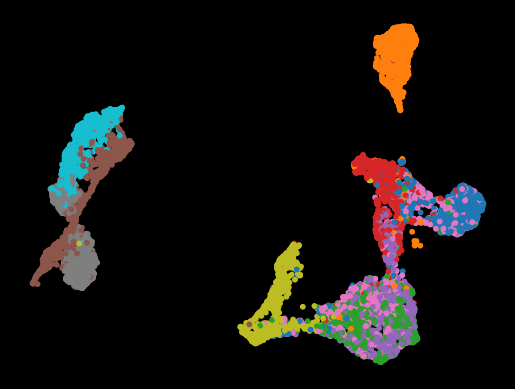

In [30]:
fig, ax = plt.subplots()
ax.scatter(x_test_2d[:, 0], x_test_2d[:, 1], c=y_test, s=10, cmap="tab10")
ax.axis("off")